# Common Libraries

In [1]:
import os, sys, optax
import numpy as np
import xarray as xr
import pandas as pd
import equinox as eqx
from tqdm import tqdm, trange
import matplotlib.pylab as plt
from typing import Tuple, Dict

"""
Setting for GPU acceleration
"""
os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("PYOPENGL_PLATFORM", "egl")
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false" # limit jax and TF from consuming all GPU memory

# Jax
import jax
jax.config.update("jax_enable_x64", True)
from jax import numpy as jnp
from jaxtyping import Float, Array

# Mujoco
import mujoco

# Custom Libraries

In [2]:
sys.path.append("/home/seojin/Tools/biomechanics/MonocularBiomechanics")
from monocular_demos.biomechanics_mjx.forward_kinematics import ForwardKinetics
from monocular_demos.biomechanics_mjx.monocular_trajectory import KineticsWrapper
sys.path.append("/home/seojin/Seojin_commonTool/Module")
from vis_3D import Plotter3D, build_3d_dataset
from sj_array import get_ACS_orientation_mat, get_ACS_explicit_orientation
from mujoco_util import get_body_pos, get_site_pos

In [3]:
# construct a loss function between the forward pass through the forward kinematic
# implicit representation and the resulting keypoint and the detected keypoitns
def loss(model: KineticsWrapper,
         x: Float[Array, "times"],
         y: Float[Array, "times keypoints 3"],
         target_site_idx,
         site_offset_regularization = 1e-1) -> Tuple[Float, Dict]:

    timestamps = x
    keypoints3d = y # unit: m
    metrics = {}

    # NOTE: steps is an make sure this retraces for different dimensions
    (state, constraints, next_states), (ang, vel, action), _ = model(
        timestamps,
        skip_vel=True,
        skip_action=True,
    )

    pred_kp3d = state.site_xpos[:, target_site_idx, :] # unit: m, shape: (#datas, #sites, 3)
    l = jnp.mean((pred_kp3d - keypoints3d) ** 2) * 100 # so in cm
    metrics["kp_err"] = l

    # regularize marker offset
    l_site_offset = jnp.sum(jnp.square(model.site_offsets))
    l += l_site_offset * site_offset_regularization

    # make loss the first key in the dictionary by popping and building a new dictionary with the rest
    metrics = {"loss": l, **metrics}

    return l, metrics

@eqx.filter_jit
def step(model, opt_state, data, loss_grad, optimizer, target_site_idx, **kwargs):
    x, targets = data

    (val, metrics), grads = loss_grad(model, x=x, y=targets, target_site_idx=target_site_idx, **kwargs)
    updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(model, eqx.is_inexact_array))
    model = eqx.apply_updates(model, updates) # Update model with preserving immutable property
    
    return val, model, opt_state, metrics

In [4]:
class ConstrainedForwardKinetics(ForwardKinetics):
    couplings: tuple = eqx.field(static=True)

    def __init__(self, xml_path, **kwargs):
        super().__init__(xml_path, **kwargs)

        # Parse equality constraint of MujoCo XML
        couplings = []
        for i in range(self.model.neq):
            if self.model.eq_type[i] == mujoco.mjtEq.mjEQ_JOINT:
                dep_idx = self.model.eq_obj1id[i]  # 종속 관절 인덱스 (예: sternoclavicular_r2)
                ind_idx = self.model.eq_obj2id[i]  # 독립 관절 인덱스 (예: shoulder_elv)
                polycoef = tuple(float(x) for x in self.model.eq_data[i][:5])  # 다항식 계수 [p0, p1, p2, p3, p4]
                couplings.append((dep_idx, ind_idx, polycoef))
                
        self.couplings = tuple(couplings)

    def __call__(self, joint_angles, scale, **kwargs):
        # Calculate dependent joint angles based on independent joint angles
        # q_dep = p0 + p1*q_ind + p2*(q_ind^2) + p3*(q_ind^3) + p4*(q_ind^4)
        for dep_idx, ind_idx, poly in self.couplings:
            q_ind = joint_angles[..., ind_idx]
            q_dep = poly[0] + poly[1] * q_ind + poly[2] * (q_ind ** 2) + poly[3] * (q_ind ** 3) + poly[4] * (q_ind ** 4)
            joint_angles = joint_angles.at[..., dep_idx].set(q_dep)
            
        return super().__call__(joint_angles, scale, **kwargs)

# Params

In [5]:
model_path = "/mnt/sdb2/DeepProprioception/Projects/DP02_emg/Myosuite/muscle_mimic_mocap/Scale/muscle_mimic_mocap_sites.xml"
pose3d_path = "/mnt/sdb2/DeepProprioception/Projects/DP02_emg/pose_estimation/body/smpl/run1_keypoint_egocentric.nc"

# Constants

In [6]:
# SMPL <-> Muscle Mimic body name
mapping_smpl_mm = {
    "R_Shoulder" : "humerus_r",
    "R_Elbow" : "ulna_r",
    "R_Wrist" : "lunate_r",
}

visualize_coords = "LAS"
ref_orientation = ["RL", "AP", "IS"]
video_frequency = 30
marker_coords = "LPS"
ref_coords = "RAI"
data_range = np.arange(10)

# Initialization

In [7]:
plotter = Plotter3D(visualize_coord_order = visualize_coords)

# Make model

In [8]:
# fk = ForwardKinetics(xml_path = model_path)
fk = ConstrainedForwardKinetics(xml_path = model_path)

actuator_names = np.array([mujoco.mj_id2name(fk.model, mujoco.mjtObj.mjOBJ_ACTUATOR, i) for i in range(fk.model.nu)])

body_names = np.array([mujoco.mj_id2name(fk.model, mujoco.mjtObj.mjOBJ_BODY, i) for i in range(fk.model.nbody)])
excludes = ["world", "Bimanual", "root"]
body_segment_names = body_names[np.isin(body_names, excludes) == False]

joint_names = np.array([mujoco.mj_id2name(fk.model, mujoco.mjtObj.mjOBJ_JOINT, i) for i in range(fk.model.njnt)])
site_names = np.array([mujoco.mj_id2name(fk.model, mujoco.mjtObj.mjOBJ_SITE, i) for i in range(fk.model.nsite)])

mimic_site_idx = jnp.array([fk.site_names.index(f"{name}_Mimic_Site") for name in mapping_smpl_mm])

/tmp/ipykernel_210632/3296155470.py:2: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  fk = ConstrainedForwardKinetics(xml_path = model_path)


# Make scale mix

Each key in mappings represents a segment group, and the corresponding list contains the subsegments belonging to that group

In [9]:
# Scale mix
mappings = {
    "torso" : ["thorax", "cervical_spine"],
    "shoulder_r" : ["clavicle_r", "scapula_r"],
    "upperarm_r" : ["humerus_r"],
    "forearm_r" : ["radius_r", "ulna_r"],
    "overall" : body_segment_names,
}

scale_mixer = jnp.array([
    [1.0 if body in child_segments else 0.0 
     for segment, child_segments in mappings.items()]
    for body in body_names
])

In [10]:
"""
KineticsWrapper consists of a neural network and a forward kinematics module, 
    where the scaling factor for each body segment is computed from body_scale and scale_mixer

Property
    - NonLearnable
        - scale_mixer

    - Learnable
        - body_scale
        - site_offsets: offset of each site
"""
model = KineticsWrapper(fk, scale_mixer = scale_mixer)

/tmp/ipykernel_210632/1986745145.py:13: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  model = KineticsWrapper(fk, scale_mixer = scale_mixer)


# Load data & Preprocessing

In [11]:
filtered_times = data_range * (1 / video_frequency)
kp_ds = xr.open_dataset(pose3d_path, engine = "netcdf4")
kp_ds = kp_ds.sel(Time = filtered_times)
pose_3d = kp_ds["3D"].to_numpy()

ones = np.ones((*pose_3d.shape[:-1], 1))
pose_3d_homo = np.concatenate([pose_3d, ones], axis=-1)

# Making rotation matrix for coordinate system alignment
reorient_M = get_ACS_orientation_mat(marker_coords, ref_coords)

# Making offset for origin correction
kp_shoulder_loc = kp_ds.sel(Time = 0, Label = "R_Shoulder")["3D"].to_numpy()

mimic_site_model = mujoco.MjModel.from_xml_path(model_path)
mimic_site_data = mujoco.MjData(mimic_site_model)
site_pos_df = get_site_pos(mimic_site_model, mimic_site_data)
model_shoulder_loc = site_pos_df[site_pos_df["site_name"] == "R_Shoulder_Mimic_Site"][["global_x", "global_y", "global_z"]].to_numpy()[0]
offset = model_shoulder_loc - (kp_shoulder_loc @ reorient_M.T)

# Making transform matrix
T_mat = np.eye(4)
T_mat[:3, :3] = reorient_M.T
T_mat[3, :3] = offset

# Transform
transformed_pose_3d_homo = pose_3d_homo @ T_mat
preprocessed_marker_ds = build_3d_dataset(
                             var_name='3D',
                             data=transformed_pose_3d_homo[:, :, :3],
                             dims=('Time', 'Label', 'Coord'),
                             coords={
                                 'Time': filtered_times,
                                 'Label': kp_ds.Label.values,
                                 'Coord': ref_orientation,
                             },
                         )
target_kp_array = preprocessed_marker_ds.sel(Label = list(mapping_smpl_mm.keys()))["3D"].to_numpy()

# Make dataset
timestamps = jnp.arange(len(transformed_pose_3d_homo)) / video_frequency
dataset = (timestamps, target_kp_array)

In [12]:
mj_model = mujoco.MjModel.from_xml_path(model_path)
mj_data = mujoco.MjData(mj_model)

body_pos_df = get_body_pos(mj_model, mj_data)

model_body_ds = build_3d_dataset(
                    var_name='3D',
                    data=np.expand_dims(body_pos_df[['global_x', 'global_y', 'global_z']].to_numpy(), 0),
                    dims=('Time', 'Label', 'Coord'),
                    coords={
                        'Time': [0],
                        'Label': body_pos_df.body_name.values,
                        'Coord': ref_orientation,
                    },
                )

plotter.plot_multiple_datasets([model_body_ds.sel(Time = [0]), preprocessed_marker_ds.sel(Time = [0])],
                               dataset_names = ["Model", "SMPL Keypoints"])

# Calculate loss

In [13]:
results = model(timestamps, skip_vel = True, skip_action = True)

kinetics_output = results[0]
trajectory_output = results[1]

state = kinetics_output[0]
constraints = kinetics_output[1]
next_states = kinetics_output[2]

joint_angle = trajectory_output[0]
joint_velocity = trajectory_output[1]
action = trajectory_output[2]

In [14]:
pred_kp3d = state.site_xpos[:, mimic_site_idx, :]
correct_kp3d = dataset[1]

In [15]:
site_offset_regularization = 1e-1

In [16]:
l = jnp.mean((pred_kp3d - correct_kp3d) ** 2) * 100 # so in cm

metrics = {}
metrics["kp_err"] = l

# regularize marker offset
l_site_offset = jnp.sum(jnp.square(model.site_offsets))
l += l_site_offset * site_offset_regularization

In [17]:
# make loss the first key in the dictionary by popping and building a new dictionary with the rest
metrics = {"loss": l, **metrics}

# Fit model

In [18]:
lr_end_value = 1e-8
lr_init_value = 1e-4
max_iters: int = 500
clip_by_global_norm = 0.1
n_models = 10

In [19]:
# work out the transition steps to make the desired schedule
transition_steps = 10
lr_decay_rate = (lr_end_value / lr_init_value) ** (1.0 / (max_iters // transition_steps))
learning_rate = optax.warmup_exponential_decay_schedule(init_value=0,
                                                        warmup_steps=0,
                                                        peak_value=lr_init_value,
                                                        end_value=lr_end_value,
                                                        decay_rate=lr_decay_rate,
                                                        transition_steps=transition_steps)

In [20]:
optimizer = optax.chain(optax.adamw(learning_rate=learning_rate, b1=0.8, weight_decay=1e-5),
                        optax.zero_nans(),
                        optax.clip_by_global_norm(clip_by_global_norm))

In [21]:
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

In [22]:
loss_grad = eqx.filter_value_and_grad(loss, has_aux=True)

In [23]:
probe_opt_idx = np.arange(0, max_iters, max_iters/n_models)

models = []
evaluations = []
for i in trange(max_iters):
    val, model, opt_state, metrics = step(model, opt_state, dataset, loss_grad, optimizer, target_site_idx = mimic_site_idx)

    """
    x, targets = dataset
    (loss, metrics), gradients = loss_grad(model, x=x, y=targets, target_site_idx = mimic_site_idx) # metrics: auxiliary data
    updates, opt_state = optimizer.update(gradients, opt_state, eqx.filter(model, eqx.is_inexact_array))
    model = eqx.apply_updates(model, updates)
    """
    
    # Print optimization result
    if np.isin(i, probe_opt_idx):
        metrics = {k: v.item() for k,v in metrics.items()}
        print(metrics)
        
        evaluations.append(metrics)
        models.append(model)

  0%|          | 1/500 [00:54<7:35:49, 54.81s/it]

{'kp_err': 4.411260491582892, 'loss': 4.411260491582892}


 17%|█▋        | 83/500 [01:38<02:37,  2.64it/s] 

{'kp_err': 0.030122533332199986, 'loss': 0.03012382212652886}


 25%|██▌       | 126/500 [01:38<00:59,  6.27it/s]

...

 85%|████████▍ | 424/500 [01:40<00:00, 161.96it/s]

{'kp_err': 0.02552106813465679, 'loss': 0.025525371181593197}


 97%|█████████▋| 483/500 [01:40<00:00, 179.71it/s]

{'kp_err': 0.02551643431659155, 'loss': 0.02552074236761058}


100%|██████████| 500/500 [01:40<00:00,  4.97it/s] 


# Optimization result

Text(0, 0.5, 'Loss')

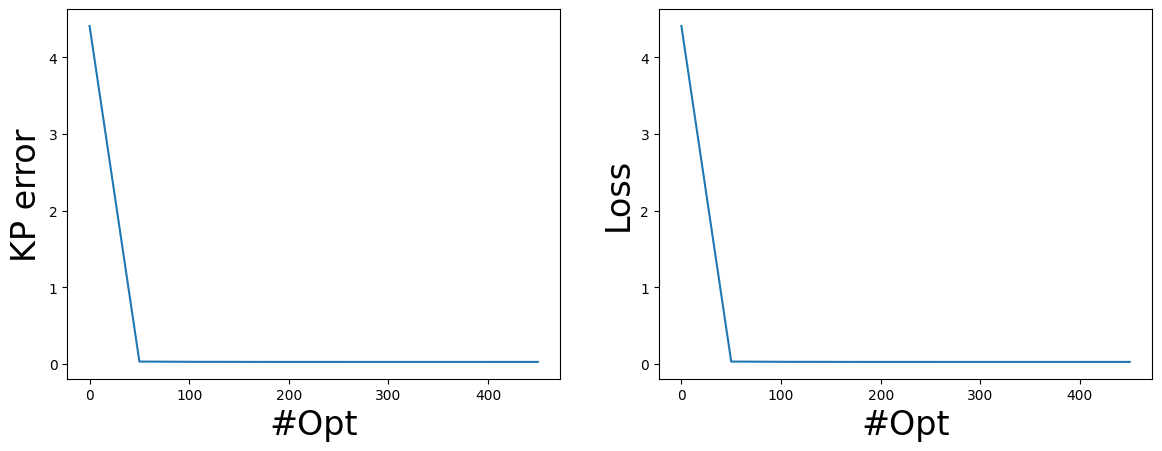

In [24]:
probe_opt_idx = np.arange(0, max_iters, max_iters/n_models)

fig, axes = plt.subplots(1, 2)
fig.set_figwidth(14)

evaluations = pd.DataFrame(evaluations)
axes[0].plot(probe_opt_idx, evaluations["kp_err"])
axes[0].set_xlabel("#Opt", size = 24)
axes[0].set_ylabel("KP error", size = 24)

axes[1].plot(probe_opt_idx, evaluations["loss"])
axes[1].set_xlabel("#Opt", size = 24)
axes[1].set_ylabel("Loss", size = 24)

# Visualization

## Keypoints

In [25]:
sel_opt_idx = [0, len(models) - 1]

In [30]:
body_ds_list = []
site_ds_list = []
constraints_list = []
for opt_i in sel_opt_idx:
    (state, constraints, next_states), (ang, vel, action), _ = models[opt_i](timestamps,
                                                                             skip_vel=True,
                                                                             skip_action=True)

    body_ds_list.append(build_3d_dataset(
                            var_name='3D',
                            data=state.xpos,
                            dims=('Time', 'Label', 'Coord'),
                            coords={
                                'Time': np.array(timestamps),
                                'Label': body_names,
                                'Coord': ref_orientation,
                            },
                        ))
    
    site_ds_list.append(build_3d_dataset(
                            var_name='3D',
                            data=state.site_xpos,
                            dims=('Time', 'Label', 'Coord'),
                            coords={
                                'Time': np.array(timestamps),
                                'Label': site_names,
                                'Coord': ref_orientation,
                            },
                        ))

    constraints_list.append(constraints)

In [27]:
smpl_pos = preprocessed_marker_ds.sel(Time = np.array(timestamps))

In [28]:
plotter.plot_multiple_datasets([smpl_pos] + body_ds_list,
                               dataset_names = ["KeyPoint"] + [f"Opt {i}" for i in sel_opt_idx])

## Constraint violation

In [35]:
constraints_list

[ConstraintViolations(equality_violation=Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float64), limit_violations=Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float64), friction_violations=Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float64), contact_violations=Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float64)),
 ConstraintViolations(equality_violation=Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float64), limit_violations=Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float64), friction_violations=Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float64), contact_violations=Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float64))]

# Result

In [92]:
sel_model_i = len(models) - 1

In [94]:
model = models[sel_model_i]

In [95]:
body_scale_vals = np.array(model.body_scale).flatten()
final_body_scales = (1.0 + np.array(model.scale_mixer) @ body_scale_vals).flatten()
body_names = ["world"] + list(model.forward.body_names)
scale_df = pd.DataFrame({
    "Segment": body_names,
    "Scale_Factor": final_body_scales,
})

scale_df

,Segment,Scale_Factor
0,world,1.000000
1,Bimanual,1.000000
2,root,1.000000
3,thorax,0.998154
4,cervical_spine,0.998154
5,clavicle_r,0.997811
6,clavphant_r,0.998737
7,scapula_r,0.997811
8,scapphant_r,0.998737
9,humphant_r,0.998737


In [96]:
offsets_mm = np.array(model.site_offsets[mimic_site_idx]) * 1000.0   # m -> mm 변환
total_shift_mm = np.linalg.norm(offsets_mm, axis=-1)

site_names = np.array(model.forward.site_names)[mimic_site_idx]

offset_df = pd.DataFrame({
    "Site_Name": site_names,
    "Offset_X (mm)": offsets_mm[:, 0],
    "Offset_Y (mm)": offsets_mm[:, 1],
    "Offset_Z (mm)": offsets_mm[:, 2],
    "Total_Shift (mm)": total_shift_mm
})

print("\n=== [2] 사이트(마커)별 오프셋 이동량 (이동량 큰 순서) ===")
display(offset_df.sort_values(by="Total_Shift (mm)", ascending=False))


=== [2] 사이트(마커)별 오프셋 이동량 (이동량 큰 순서) ===


,Site_Name,Offset_X (mm),Offset_Y (mm),Offset_Z (mm),Total_Shift (mm)
0,R_Shoulder_Mimic_Site,4.710760,-4.700208,1.715348,6.872091
1,R_Elbow_Mimic_Site,2.853682,2.347509,-0.666552,3.754809
2,R_Wrist_Mimic_Site,0.333041,1.514668,-0.747766,1.721712
